# Inference for Tennis Pose Detection

With all models correctly trained and stored in `exports/`, we utilize `InferencePipeline` in `inference/inference.py` to tie these models all together.

Since we're loading these weights into each model, we use state dictionaries to load the models:
1. `exports/bbox_best.pt` - state_dict for bbox
2. `exports/keypoint_best_state_dict.pt` - state_dict for keypoint
3. `exports/pose_best.pt` - checkpoint dict for pose, but contains state_dict inside

 `InferencePipeline` requires that we directly pass the model object into its init, so we must init these model objects outside before creating InferencePipeline.

 The inference pipeline is as follows:
 1. Input RGB image of size (1280, 720)  
 $\rarr$ Convert to PIL    

 2. PIL representation of size (1280, 720)  
 $\rarr$ Convert to Tensor  

 3. Tensor representation of size (3, 720, 1280)  
 $\rarr$ **Pass into Stage One BBox Detection Model** 

 4. Bbox vector w/ values (x_min, y_min, bb_width, bb_height)  
 $\rarr$ Crop PIL representation with Bbox vector  

 5. Cropped PIL representation of size (bb_width, bb_height)  
 $\rarr$ Letterbox resizing with resize hyparameter (set_width, set_height)  

 6. Resized PIL representation of size (set_width, set_height)  
 $\rarr$ **Pass into Stage Two Keypoint Detection Model**  

 7. Keypoint vector of size (18, 3)  
 $\rarr$ **Pass into Stage Three Pose Classification Model**  

 8. Confidence vector of size (4, 1)  
 $\rarr$ Take max index  

 9. Pose index prediction of size (1,)  

## Setup

In [57]:
from pathlib import Path
import random
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from torchvision import transforms

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from models.bbox_detection import BBoxDetectionModel
from models.keypoint_detection import KeypointDetectionModel
from models.pose_classification import PoseClassificationModel
from preprocessing.pil_preprocessing import crop_pil, letterbox_resize
from preprocessing.tensor_preprocessing import heatmaps_to_keypoints, normalize_keypoints_xy
from inference.inference import InferencePipeline

In [58]:
if not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

EXPORT_DIR = PROJECT_ROOT / "exports"
# DATASET_ROOT = (
#     PROJECT_ROOT
#     / "datasets"
#     / "orvile"
#     / "tennis-player-actions-dataset"
#     / "versions"
#     / "1"
#     / "Tennis Player Actions Dataset for Human Pose Estimation"
# )
# IMAGES_ROOT = DATASET_ROOT / "images"

DATASET_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "walnut"
)
IMAGES_ROOT = DATASET_ROOT

CLASS_NAMES = ["backhand", "forehand", "ready_position", "serve"]
BBOX_IMAGE_SIZE = (256, 256)
USE_SEED = False
if USE_SEED:
    SEED = 42
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {device}")
print(f"BBox model input size (H, W): {BBOX_IMAGE_SIZE}")

Project root: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection
Device: cpu
BBox model input size (H, W): (256, 256)


In [59]:
bbox_export_path = EXPORT_DIR / "bbox_best.pt"
keypoint_export_path = EXPORT_DIR / "keypoint_best_state_dict.pt"
pose_export_path = EXPORT_DIR / "pose_best.pt"

required_exports = [bbox_export_path, keypoint_export_path, pose_export_path]
missing_exports = [str(path) for path in required_exports if not path.exists()]

if missing_exports:
    raise FileNotFoundError(
        "Missing required export artifacts (exports-only mode):\n"
        + "\n".join(f"- {path}" for path in missing_exports)
    )

print("All required export artifacts found:")
for path in required_exports:
    print(f"- {path}")

All required export artifacts found:
- /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/exports/bbox_best.pt
- /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/exports/keypoint_best_state_dict.pt
- /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/exports/pose_best.pt


## Setup Models

### BBox Detection Model

In [60]:
bbox_model = BBoxDetectionModel().to(device)
bbox_state = torch.load(bbox_export_path, map_location=device)

if not isinstance(bbox_state, dict):
    raise ValueError("Unexpected bbox export format. Expected state_dict dictionary.")

bbox_model.load_state_dict(bbox_state)
bbox_model.eval()

print("BBox model loaded from:", bbox_export_path)

BBox model loaded from: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/exports/bbox_best.pt


### Keypoint Detection Model

In [61]:
keypoint_payload = torch.load(keypoint_export_path, map_location="cpu")

if isinstance(keypoint_payload, dict) and "model_state" in keypoint_payload:
    keypoint_state = keypoint_payload["model_state"]
    num_keypoints = int(keypoint_payload.get("num_keypoints", 18))
    keypoint_h = int(keypoint_payload.get("image_height", 128))
    keypoint_w = int(keypoint_payload.get("image_width", 128))
elif isinstance(keypoint_payload, dict):
    keypoint_state = keypoint_payload
    num_keypoints = 18
    keypoint_h, keypoint_w = 128, 128
else:
    raise ValueError("Unexpected keypoint export format.")

keypoint_model = KeypointDetectionModel(num_keypoints=num_keypoints).to(device)
keypoint_model.load_state_dict(keypoint_state)
keypoint_model.eval()

keypoint_image_size = (keypoint_h, keypoint_w)
print("Keypoint model loaded from:", keypoint_export_path)
print("Keypoint model input size (H, W):", keypoint_image_size)
print("Num keypoints:", num_keypoints)

Keypoint model loaded from: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/exports/keypoint_best_state_dict.pt
Keypoint model input size (H, W): (128, 128)
Num keypoints: 18


### Pose Classification Model

In [62]:
pose_checkpoint = torch.load(pose_export_path, map_location="cpu")

if not isinstance(pose_checkpoint, dict) or "model_state" not in pose_checkpoint:
    raise ValueError("Unexpected pose export format. Expected checkpoint dict with 'model_state'.")

pose_state = pose_checkpoint["model_state"]
pose_label_names = pose_checkpoint.get("label_names", CLASS_NAMES)

if pose_label_names is None:
    pose_label_names = CLASS_NAMES

num_pose_classes = len(pose_label_names)
pose_model = PoseClassificationModel(num_keypoints=num_keypoints, num_classes=num_pose_classes).to(device)
pose_model.load_state_dict(pose_state)
pose_model.eval()

print("Pose model loaded from:", pose_export_path)
print("Pose classes:", pose_label_names)

Pose model loaded from: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/exports/pose_best.pt
Pose classes: ['Backhand', 'Forehand', 'Ready_Position', 'Serve']


## Setup Pipeline

In [63]:
pipeline = InferencePipeline(
    bbox_detection=bbox_model,
    keypoint_detection=keypoint_model,
    pose_detection=pose_model,
    bbox_image_size=BBOX_IMAGE_SIZE,
    keypoint_image_size=keypoint_image_size,
)

bbox_transform = transforms.Compose([
    transforms.Resize(BBOX_IMAGE_SIZE),
    transforms.ToTensor(),
])

print("InferencePipeline created.")
print("Configured bbox image size (H, W):", BBOX_IMAGE_SIZE)
print("Configured keypoint image size (H, W):", keypoint_image_size)


def pick_random_image(images_root: Path, class_names: list[str]) -> tuple[Path, str]:
    valid_paths: list[tuple[Path, str]] = []
    for class_name in class_names:
        class_dir = images_root / class_name
        if not class_dir.exists():
            continue
        for path in class_dir.glob("*"):
            if path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                valid_paths.append((path, class_name))

    if not valid_paths:
        raise FileNotFoundError(f"No valid images found under {images_root}")

    return random.choice(valid_paths)


def to_xyxy_pixels(bbox_pred: torch.Tensor, image_width: int, image_height: int) -> tuple[int, int, int, int]:
    bbox = bbox_pred.detach().cpu().view(-1)
    if bbox.numel() != 4:
        raise ValueError(f"Expected bbox prediction with 4 values, got shape {tuple(bbox_pred.shape)}")

    x, y, w, h = bbox.tolist()

    likely_normalized = max(abs(x), abs(y), abs(w), abs(h)) <= 1.5
    if likely_normalized:
        x = x * image_width
        y = y * image_height
        w = w * image_width
        h = h * image_height

    x1 = int(round(x))
    y1 = int(round(y))
    x2 = int(round(x + w))
    y2 = int(round(y + h))

    x1 = max(0, min(x1, image_width - 1))
    y1 = max(0, min(y1, image_height - 1))
    x2 = max(x1 + 1, min(x2, image_width))
    y2 = max(y1 + 1, min(y2, image_height))

    return x1, y1, x2, y2


def draw_bbox(image: Image.Image, xyxy: tuple[int, int, int, int]) -> Image.Image:
    out = image.copy()
    draw = ImageDraw.Draw(out)
    draw.rectangle(xyxy, outline="red", width=3)
    return out

InferencePipeline created.
Configured bbox image size (H, W): (256, 256)
Configured keypoint image size (H, W): (128, 128)


Selected image: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/datasets/walnut/ready_position/cindy_ready_position.png
Class folder: ready_position
Input PIL size (W, H): (3840, 2160)


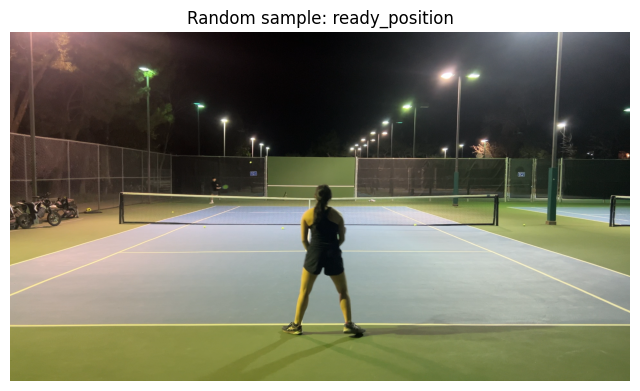

In [64]:
sample_path, sample_class = pick_random_image(IMAGES_ROOT, CLASS_NAMES)
pil_image = Image.open(sample_path).convert("RGB")
img_w, img_h = pil_image.size

print("Selected image:", sample_path)
print("Class folder:", sample_class)
print("Input PIL size (W, H):", (img_w, img_h))

plt.figure(figsize=(8, 5))
plt.imshow(pil_image)
plt.title(f"Random sample: {sample_class}")
plt.axis("off")
plt.show()

Stage 1 original tensor shape (C, H, W): (3, 2160, 3840)
Stage 1 bbox-model tensor shape (C, H, W): (3, 256, 256)
BBox raw prediction (normalized xywh): [0.45459992 0.40199992 0.09255227 0.35014898]
BBox converted xyxy (pixels): (1746, 868, 2101, 1625)
Stage 2 cropped PIL size (W, H): (355, 757)
Stage 2 resized PIL size (W, H): (128, 128)


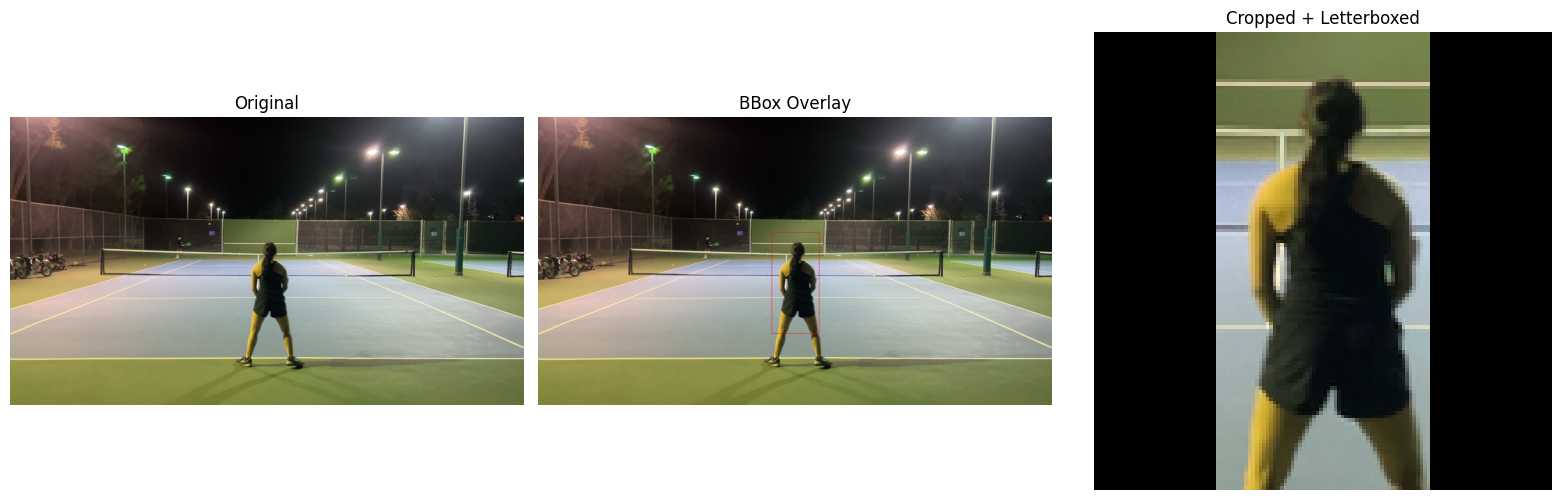

In [65]:
to_tensor = transforms.ToTensor()

with torch.no_grad():
    image_tensor = to_tensor(pil_image).to(device)
    bbox_input_tensor = bbox_transform(pil_image).to(device)
    bbox_pred = bbox_model(bbox_input_tensor.unsqueeze(0)).squeeze(0)

bbox_xyxy = to_xyxy_pixels(bbox_pred, img_w, img_h)
cropped_pil = crop_pil(pil_image, bbox_xyxy)
resized_pil = letterbox_resize(cropped_pil.copy(), size=keypoint_image_size)

print("Stage 1 original tensor shape (C, H, W):", tuple(image_tensor.shape))
print("Stage 1 bbox-model tensor shape (C, H, W):", tuple(bbox_input_tensor.shape))
print("BBox raw prediction (normalized xywh):", bbox_pred.detach().cpu().numpy())
print("BBox converted xyxy (pixels):", bbox_xyxy)
print("Stage 2 cropped PIL size (W, H):", cropped_pil.size)
print("Stage 2 resized PIL size (W, H):", resized_pil.size)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(pil_image)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(draw_bbox(pil_image, bbox_xyxy))
axes[1].set_title("BBox Overlay")
axes[1].axis("off")

axes[2].imshow(resized_pil)
axes[2].set_title("Cropped + Letterboxed")
axes[2].axis("off")

plt.tight_layout()
plt.show()

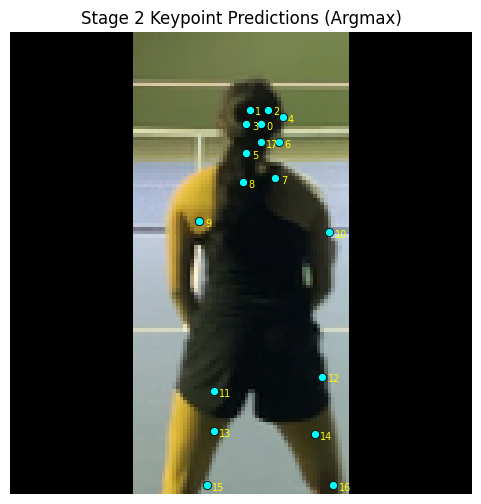

Heatmap shape (B, K, H, W): (1, 18, 128, 128)
Keypoint vector shape (K, 3): (18, 3)
First 3 keypoints [x_norm, y_norm, conf]:
[[0.54330707 0.19685039 3.6650329 ]
 [0.51968503 0.16535433 3.253841  ]
 [0.5590551  0.16535433 3.7167385 ]]


In [66]:
with torch.no_grad():
    keypoint_tensor = to_tensor(resized_pil).to(device)
    heatmaps = keypoint_model(keypoint_tensor.unsqueeze(0))
    keypoints = heatmaps_to_keypoints(heatmaps)
    keypoints_norm = normalize_keypoints_xy(keypoints, heatmaps.size(2), heatmaps.size(3)).squeeze(0)

keypoints_np = keypoints.detach().cpu().squeeze(0).numpy()
keypoints_norm_np = keypoints_norm.detach().cpu().numpy()

hmap_h, hmap_w = heatmaps.size(2), heatmaps.size(3)
pred_x = np.clip(keypoints_np[:, 0], 0, hmap_w - 1)
pred_y = np.clip(keypoints_np[:, 1], 0, hmap_h - 1)

plt.figure(figsize=(6, 6))
plt.imshow(resized_pil)
plt.scatter(pred_x, pred_y, c="cyan", s=35, edgecolors="black", linewidths=0.6)
for idx, (xk, yk, vis) in enumerate(keypoints_np):
    plt.text(xk + 1.5, yk + 1.5, str(idx), color="yellow", fontsize=7)
plt.title("Stage 2 Keypoint Predictions (Argmax)")
plt.axis("off")
plt.show()

print("Heatmap shape (B, K, H, W):", tuple(heatmaps.shape))
print("Keypoint vector shape (K, 3):", tuple(keypoints_norm_np.shape))
print("First 3 keypoints [x_norm, y_norm, conf]:")
print(keypoints_norm_np[:3])

Stage 3 confidence vector shape: (1, 4)
Confidence vector: [1.64986607e-02 2.13211770e-05 9.68907893e-01 1.45721175e-02]
Predicted index: 2
Predicted label: Ready_Position


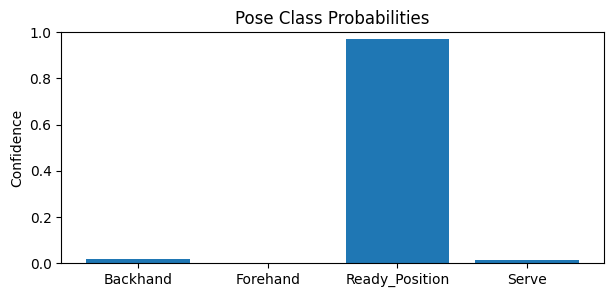

In [67]:
with torch.no_grad():
    pose_probs = pose_model(keypoints_norm)

pose_probs_np = pose_probs.detach().cpu().squeeze(0).numpy()
pred_idx = int(np.argmax(pose_probs_np))
pred_label = pose_label_names[pred_idx] if pred_idx < len(pose_label_names) else str(pred_idx)

print("Stage 3 confidence vector shape:", tuple(pose_probs.shape))
print("Confidence vector:", pose_probs_np)
print("Predicted index:", pred_idx)
print("Predicted label:", pred_label)

plt.figure(figsize=(7, 3))
plt.bar(pose_label_names, pose_probs_np)
plt.ylim(0.0, 1.0)
plt.title("Pose Class Probabilities")
plt.ylabel("Confidence")
plt.show()

In [68]:
summary_rows = [
    ("Input PIL (W,H)", str((img_w, img_h))),
    ("Stage 1 Tensor (C,H,W)", str(tuple(image_tensor.shape))),
    ("BBox xyxy (pixels)", str(bbox_xyxy)),
    ("Cropped PIL (W,H)", str(cropped_pil.size)),
    ("Resized PIL (W,H)", str(resized_pil.size)),
    ("Heatmaps (B,K,H,W)", str(tuple(heatmaps.shape))),
    ("Keypoints (K,3)", str(tuple(keypoints_norm_np.shape))),
    ("Pose probs (B,C)", str(tuple(pose_probs.shape))),
    ("Predicted label", pred_label),
]

print("Inference Summary")
for key, value in summary_rows:
    print(f"- {key}: {value}")

try:
    with torch.no_grad():
        pipeline_pose = pipeline.run_pipe(pil_image)
    pipeline_probs_np = pipeline_pose.detach().cpu().squeeze(0).numpy()
    pipeline_idx = int(np.argmax(pipeline_probs_np))
    pipeline_label = pose_label_names[pipeline_idx] if pipeline_idx < len(pose_label_names) else str(pipeline_idx)
    print("\nInferencePipeline output shape:", tuple(pipeline_pose.shape))
    print("InferencePipeline predicted label:", pipeline_label)
except Exception as error:
    print("\nInferencePipeline run_pipe check skipped due to runtime error:")
    print(error)

Inference Summary
- Input PIL (W,H): (3840, 2160)
- Stage 1 Tensor (C,H,W): (3, 2160, 3840)
- BBox xyxy (pixels): (1746, 868, 2101, 1625)
- Cropped PIL (W,H): (355, 757)
- Resized PIL (W,H): (128, 128)
- Heatmaps (B,K,H,W): (1, 18, 128, 128)
- Keypoints (K,3): (18, 3)
- Pose probs (B,C): (1, 4)
- Predicted label: Ready_Position

InferencePipeline output shape: (1, 4)
InferencePipeline predicted label: Ready_Position
